In [1]:
using Flight
using Flight.FlightLib.Linearization: delete_vars
using Flight.FlightLib.Control.Discrete: PIDParams, LQRParams
using Flight.FlightLib.Control.PIDOpt: Settings, Metrics, optimize_PID, build_PID, check_results
using ControlSystems, RobustAndOptimalControl, Plots, UnPack

includet("robot2d.jl"); using .Robot2D

In [2]:
mdl = Robot2D.Vehicle() |> Model
lss = linearize(mdl)
P = named_ss(lss)

NamedStateSpace{Continuous, Float64}
A = 
 -2.0209997423344506  40.41999484668901  64.81333998969338   0.0
  0.3652409172893585  -7.30481834578717  -4.624109636691573  0.0
  1.0                  0.0                0.0                0.0
  0.0                  1.0                0.0                0.0
B = 
 -34.2179850553981
   6.18397320278279
   0.0
   0.0
C = 
 1.0                    0.0                  0.0                 0.0
 0.0                    1.0                  0.0                 0.0
 0.0                    0.0                  1.0                 0.0
 0.0                    0.0                  0.0                 1.0
 0.005843854676629732  -0.11687709353259468  0.2202137458129348  0.0
D = 
 0.0
 0.0
 0.0
 0.0
 0.09894357124452455

Continuous-time state-space model
With state  names: ω v θ η
     input  names: m
     output names: ω v θ η τ_m


In [3]:
dampreport(P)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -3.38              |  1            |  3.38         |  0.537        |  0.296        |
| +6.71              |  -1           |  6.71         |  1.07         |  -0.149       |
| -12.7              |  1            |  12.7         |  2.01         |  0.079        |


## 0. $m \rightarrow \omega$ Response

In [4]:
P_m2ω = P[:ω, :m]

NamedStateSpace{Continuous, Float64}
A = 
 -2.0209997423344506  40.41999484668901  64.81333998969338   0.0
  0.3652409172893585  -7.30481834578717  -4.624109636691573  0.0
  1.0                  0.0                0.0                0.0
  0.0                  1.0                0.0                0.0
B = 
 -34.2179850553981
   6.18397320278279
   0.0
   0.0
C = 
 1.0  0.0  0.0  0.0
D = 
 0.0

Continuous-time state-space model
With state  names: ω v θ η
     input  names: m
     output names: ω


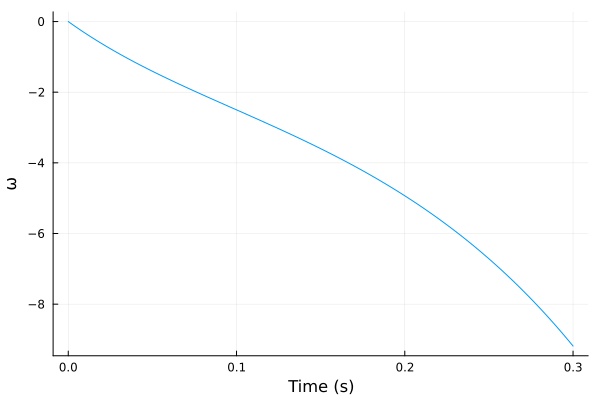

In [5]:
step(P_m2ω, 0.3) |> plot

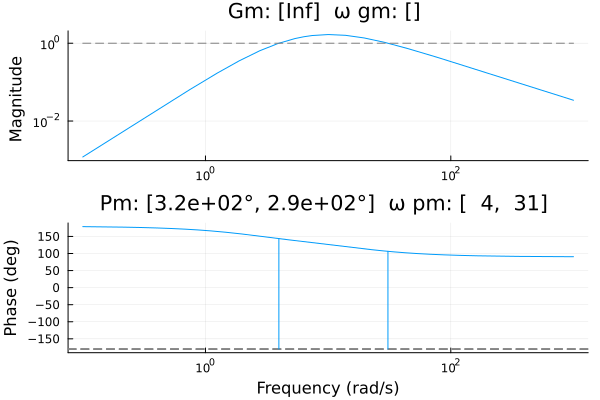

In [6]:
marginplot(P_m2ω)

|        Pole        |   Damping     |   Frequency   |   Frequency   | Time Constant |
|                    |    Ratio      |   (rad/sec)   |     (Hz)      |     (sec)     |
+--------------------+---------------+---------------+---------------+---------------+
| +0                 |  -1           |  0            |  0            |  -Inf         |
| -2.36              |  1            |  2.36         |  0.375        |  0.424        |
| +4.29              |  -1           |  4.29         |  0.682        |  -0.233       |
| -28.4              |  1            |  28.4         |  4.51         |  0.0353       |


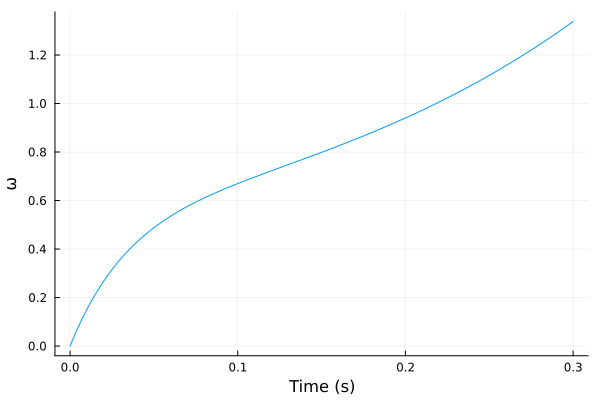

In [7]:
#define controller in series with the plant as a simple gain plus a sign
#inversion
K_ω2m = 0.5
C_ω2m = named_ss(ss(-1 * K_ω2m), :C_ω2m; u = :ω_err, y = :m)

#open loop transfer function
L_ω2m = series(C_ω2m, P_m2ω)

#closed loop transfer function
T_ω2m = output_comp_sensitivity(P_m2ω, C_ω2m)

#command to control input transfer function
CS_ω2m = G_CS(P_m2ω, C_ω2m)

dampreport(T_ω2m)

step(T_ω2m, 0.3) |> plot


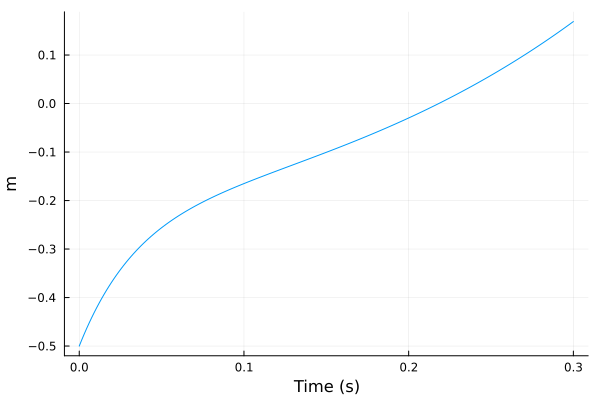

In [8]:
step(CS_ω2m, 0.3) |> plot

TODO: Apply the $\omega$ feedback to the open-loop MIMO plant P_m to obtain P_omega, then add an outer
$\theta$ loop.

In [9]:
zpk(P_m2ω)

TransferFunction{Continuous, ControlSystemsBase.SisoZpk{Float64, ComplexF64}}
                                     (1.0s - 1.5613481586342697e-15)(1.0s)
-34.2179850553981------------------------------------------------------------------------------
                 (1.0s + 12.65780721012507)(1.0s + 3.3751562931611736)(1.0s - 6.70714541516462)

Continuous-time transfer function model

In [10]:
zpk(T_ω2m)

TransferFunction{Continuous, ControlSystemsBase.SisoZpk{Float64, ComplexF64}}
                                     (1.0s - 9.444152175680528e-16)(1.0s)
17.10899252769905-----------------------------------------------------------------------------
                 (1.0s + 28.36371465308367)(1.0s + 2.357087380476589)(1.0s - 4.28599141773958)

Continuous-time transfer function model

## 1. PID Design

In [11]:
P_m2θ = P[:θ, :m]

NamedStateSpace{Continuous, Float64}
A = 
 -2.0209997423344506  40.41999484668901  64.81333998969338   0.0
  0.3652409172893585  -7.30481834578717  -4.624109636691573  0.0
  1.0                  0.0                0.0                0.0
  0.0                  1.0                0.0                0.0
B = 
 -34.2179850553981
   6.18397320278279
   0.0
   0.0
C = 
 0.0  0.0  1.0  0.0
D = 
 0.0

Continuous-time state-space model
With state  names: ω v θ η
     input  names: m
     output names: θ


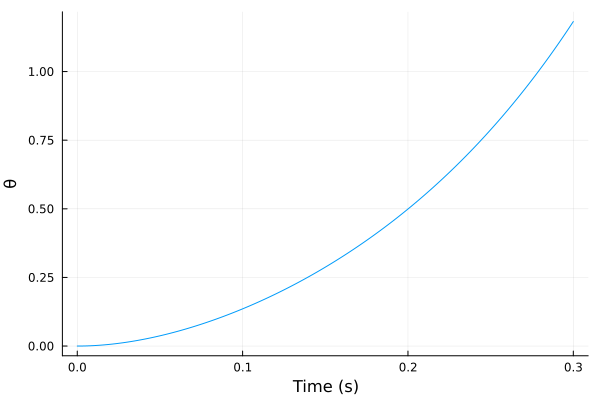

In [12]:
#include the necessary sign inversion in the plant for PID optimization
P_m2θ_opt = -P_m2θ
step(P_m2θ_opt, 0.3) |> plot

In [13]:
t_sim = 1
lower_bounds = PIDParams(; k_p = 0.0, k_i = 0.00, k_d = 0.0, τ_f = 0.002)
upper_bounds = PIDParams(; k_p = 100, k_i = 5000, k_d = 1, τ_f = 0.002)
settings = Settings(; t_sim = t_sim, lower_bounds, upper_bounds)
weights = Metrics(; Ms = 2.0, ∫e = 1.0, ef = 5.0, ∫u = 0.0, up = 0.01)
params_0 = PIDParams(; k_p = 1, k_i = 0, k_d = 0.0, τ_f = 0.005)

global_search = true
θ2m_results = optimize_PID(P_m2θ_opt; params_0, settings, weights, global_search)
θ2m_pid = build_PID(θ2m_results.params)

#return the sign inversion to the compensator
C_θ2m = -θ2m_pid
C_θ2m = named_ss(ss(C_θ2m), :C_θ2m; u = :θ_err, y = :m)

#and concatenate with the non-inverted plant
L_θ2m = series(C_θ2m, P_m2θ);

@unpack k_p, k_i, k_d, τ_f, T_i, T_d = θ2m_results.params
@show k_p, k_i, k_d, τ_f, T_i, T_d
@show θ2m_results.metrics
@show θ2m_results.exit_flag;

(k_p, k_i, k_d, τ_f, T_i, T_d) = (12.32819587040341, 68.4547364612857, 0.43691394181109733, 0.002, 0.1800926642581638, 0.03544021740115331)
θ2m_results.metrics = [1.3246477406005879, 0.21435674746393366, 0.13880206196677514, 8.712551988318674, 229.78516677595206]
θ2m_results.exit_flag = :ROUNDOFF_LIMITED


StepInfo:
Initial value:     0.000
Final value:       1.139
Step size:         1.139
Peak:              1.518
Peak time:         0.167 s
Overshoot:         33.33 %
Undershoot:         0.00 %
Settling time:     0.509 s
Rise time:         0.063 s


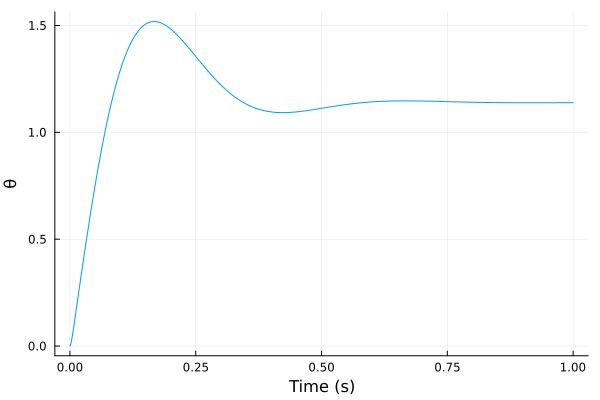

In [14]:
P_m2θ_step_SISO = step(P_m2θ_opt, t_sim)

#closed loop transfer function
T_θ2m = output_comp_sensitivity(P_m2θ, C_θ2m)
T_θ2m_step_SISO = step(T_θ2m, t_sim)
stepinfo(T_θ2m_step_SISO) |> display
T_θ2m_step_SISO |> plot
# plot!(P_m2θ_step_SISO)

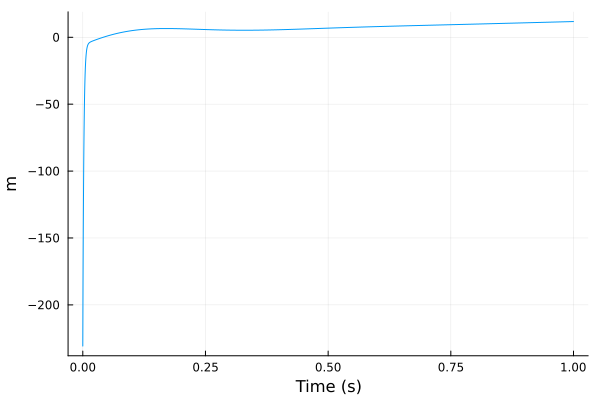

In [15]:
CS_θ2m = G_CS(P_m2θ, C_θ2m)
CS_θ2m_step = step(CS_θ2m, t_sim)
CS_θ2m_step |> plot

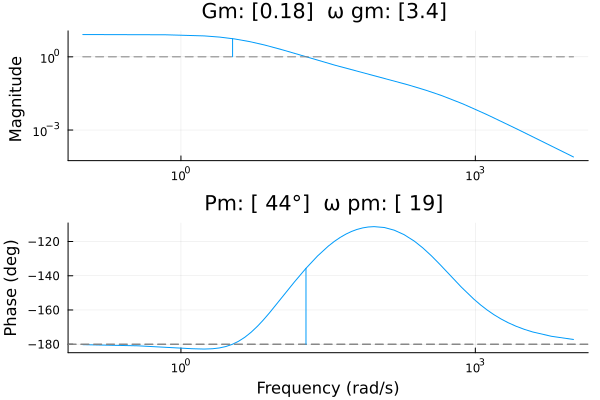

In [16]:
marginplot(L_θ2m)

┌ Warning: Keyword argument hover not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, guidefo

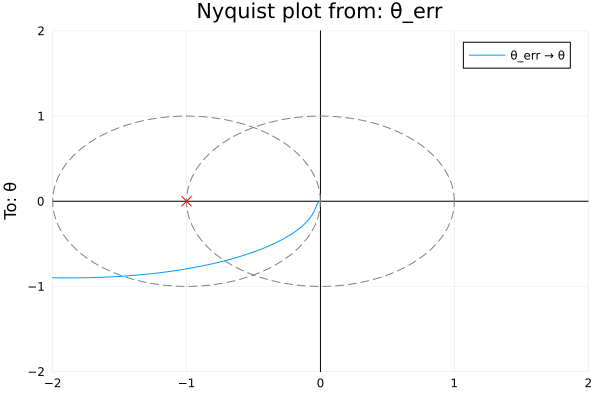

In [17]:
nyquistplot(L_θ2m; unit_circle = true, Ms_circles = [1.0])
plot!(ylims = (-2,2), xlims = (-2,2))

## 2. LQR Design

In [18]:
#reduced system with η removed
lss_red = delete_vars(lss, :η)
P_red = named_ss(lss_red)

NamedStateSpace{Continuous, Float64}
A = 
 -2.0209997423344506  40.41999484668901  64.81333998969338
  0.3652409172893585  -7.30481834578717  -4.624109636691573
  1.0                  0.0                0.0
B = 
 -34.2179850553981
   6.18397320278279
   0.0
C = 
 1.0                    0.0                  0.0
 0.0                    1.0                  0.0
 0.0                    0.0                  1.0
 0.005843854676629732  -0.11687709353259468  0.2202137458129348
D = 
 0.0
 0.0
 0.0
 0.09894357124452455

Continuous-time state-space model
With state  names: ω v θ
     input  names: m
     output names: ω v θ τ_m


We need a LQR tracker with v as command variable and integral control. See Gemini.